## **CLUSTERING**

## Palmer Penguins Dataset

### Problem Statement

    Penguins are flightless birds inhabiting primarily the Southern Hemisphere, with the one exception of Galapagos penguin, living north of the equator. They can be easily identified because of their mostly black and white colors, as well as the lack of wings, which have evolved into flippers to aid them in swimming.(Penguin Facts, Types, Habitat, Diet, Adaptations, Pictures, n.d.)

### Loading Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
 
sns.set_style("whitegrid")
RANDOM_STATE = 42


### Loading Data

In [3]:
peng = pd.read_csv(r'C:\Users\User\Desktop\Data-Science-Class\Data\penguins.csv')

In [4]:
peng.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
print("Shape:", peng.shape)
print("\nDtypes:\n", peng.dtypes)
print("\nMissing values:\n", peng.isna().sum())
print("\nDescribe:\n", peng.describe())

Shape: (344, 5)

Dtypes:
 culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object

Missing values:
 culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

Describe:
        culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
count        342.000000       342.000000         342.000000   342.000000
mean          43.921930        17.151170         214.014620  4201.754386
std            5.459584         1.974793         260.558057   801.954536
min           32.100000        13.100000        -132.000000  2700.000000
25%           39.225000        15.600000         190.000000  3550.000000
50%           44.450000        17.300000         197.000000  4050.000000
75%           48.500000        18.700000         213.750000  4750.000000
max           59.600000        21.500000        5000.000000  6300.000000


### Data Preprocessing and Cleaning

In [6]:
# Numerical columns

numeric_cols = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]
before = peng.shape[0]

In [7]:
# Drop rows missing features

peng_clean = peng.dropna(subset=numeric_cols).copy()
print(f"Rows dropped due to missing/invalid numeric data: {before - peng_clean.shape[0]}")
print("Remaining rows:", peng_clean.shape[0])

Rows dropped due to missing/invalid numeric data: 2
Remaining rows: 342


In [8]:
# Sex has some missing values

peng["sex"] = peng["sex"].fillna(peng["sex"].mode()[0])

### Exploratory Data Analysis


Correlation matrix:
                    culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
culmen_length_mm               1.00            -0.24               0.02   
culmen_depth_mm               -0.24             1.00               0.04   
flipper_length_mm              0.02             0.04               1.00   
body_mass_g                    0.60            -0.47               0.05   

                   body_mass_g  
culmen_length_mm          0.60  
culmen_depth_mm          -0.47  
flipper_length_mm         0.05  
body_mass_g               1.00  


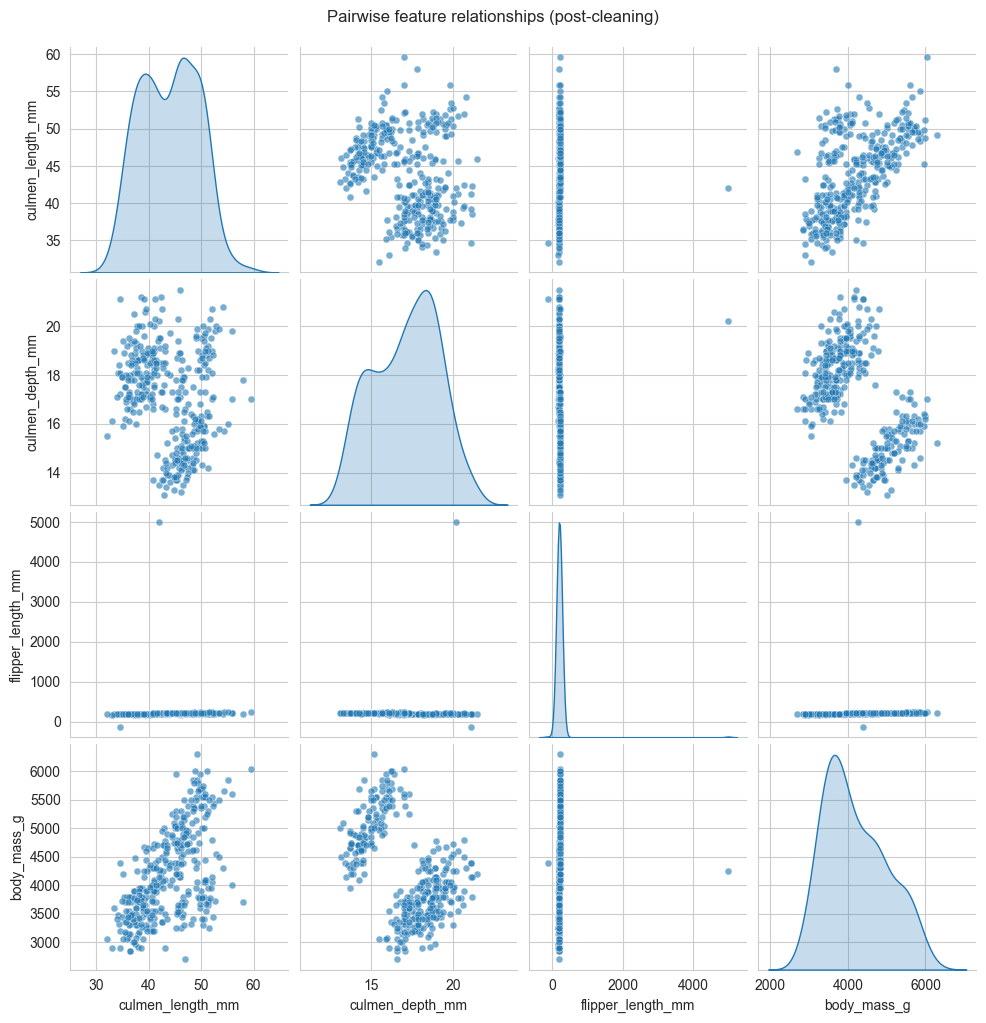

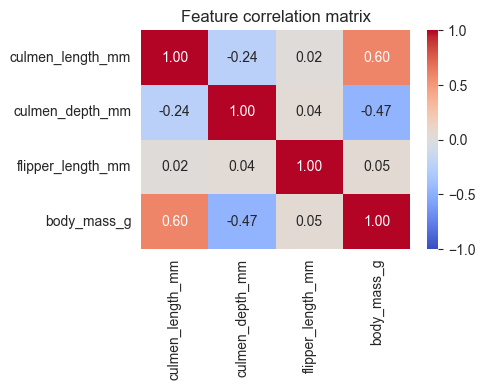

In [9]:
fig = sns.pairplot(peng_clean[numeric_cols], diag_kind="kde", plot_kws={"alpha": 0.6, "s": 25})
fig.fig.suptitle("Pairwise feature relationships (post-cleaning)", y=1.02)
 
corr = peng_clean[numeric_cols].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Feature correlation matrix")
plt.tight_layout()
 
print("\nCorrelation matrix:\n", corr.round(2))

### Feature Engineering and Selection

In [10]:
X = peng_clean[numeric_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
print("\nScaled feature means (~0):", X_scaled.mean(axis=0).round(3))
print("Scaled feature stds (~1):", X_scaled.std(axis=0).round(3))


Scaled feature means (~0): [ 0. -0.  0.  0.]
Scaled feature stds (~1): [1. 1. 1. 1.]


### Model Pipeline


Tuning results:
    k  inertia  silhouette  davies_bouldin
0  2  823.440       0.484           0.823
1  3  481.947       0.497           0.549
2  4  309.047       0.477           0.634
3  5  241.654       0.444           0.677
4  6  180.459       0.406           0.754
5  7  154.538       0.396           0.767
6  8  140.144       0.379           0.863

Best k by silhouette score: 3


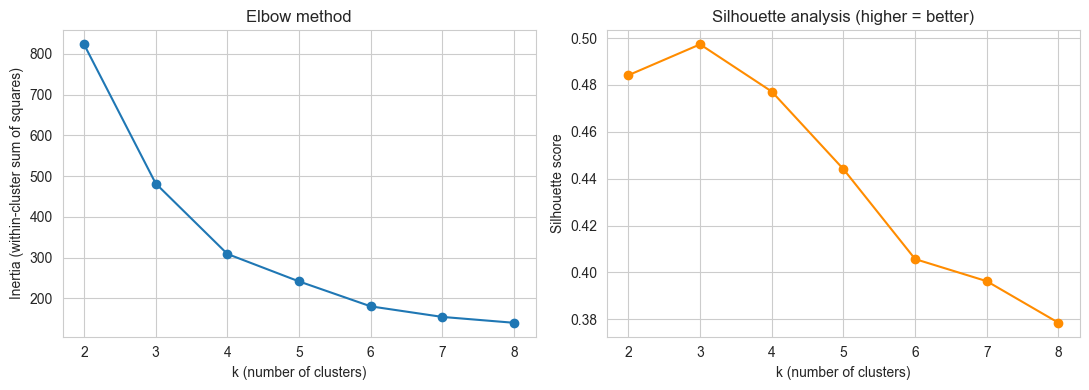

In [13]:
k_range = range(2, 9)
inertias = []
sil_scores = []
db_scores = []
 
for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
 
tuning_df = pd.DataFrame({
    "k": list(k_range),
    "inertia": inertias,
    "silhouette": sil_scores,
    "davies_bouldin": db_scores
})
print("\nTuning results:\n", tuning_df.round(3))
 
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].set_title("Elbow method")
 
axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette analysis (higher = better)")
 
plt.tight_layout()
 
best_k = tuning_df.loc[tuning_df["silhouette"].idxmax(), "k"]
print(f"\nBest k by silhouette score: {int(best_k)}")

## Evaluate - PCA visualization 


PCA explained variance ratio: [0.471 0.253] (total: 72.5%)


KeyError: 2

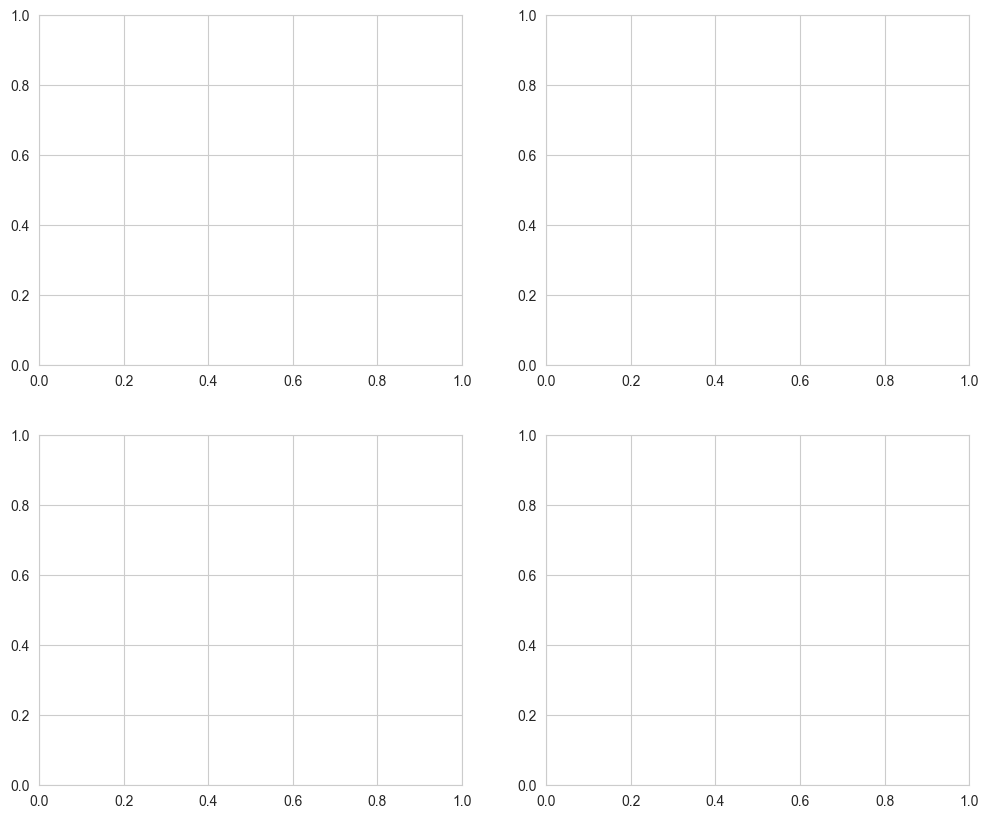

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA explained variance ratio: {pca.explained_variance_ratio_.round(3)} "
      f"(total: {pca.explained_variance_ratio_.sum():.1%})")
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, k in enumerate([2, 3]):
    labels = [k]["labels"]
    centers_pca = pca.transform(peng_clean[k]["model"].cluster_centers_)
 
    # Scatter in PCA space
    ax = axes[0, i]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", alpha=0.7, s=30)
    ax.scatter(centers_pca[:, 0], centers_pca[:, 1], c="red", marker="X", s=200,
               edgecolor="black", label="centroids")
    ax.set_title(f"K-Means clusters (k={k}) in PCA space")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

    # Silhouette plot
    ax2 = axes[1, i]
    sample_sil = silhouette_samples(X_scaled, labels)
    y_lower = 10
    for c in range(k):
        c_vals = np.sort(sample_sil[labels == c])
        y_upper = y_lower + len(c_vals)
        ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, c_vals, alpha=0.7)
        y_lower = y_upper + 10
    ax2.axvline(peng_clean[k]["silhouette"], color="red", linestyle="--",
                label=f"avg={peng_clean[k]['silhouette']:.2f}")
    ax2.set_title(f"Per-sample silhouette (k={k})")
    ax2.set_xlabel("Silhouette coefficient")
    ax2.set_ylabel("Samples per cluster")
    ax2.legend()

plt.tight_layout()

In [16]:
print("\nk=3 clusters vs sex (cross-tab, sex was NOT used to fit the model):")
print(pd.crosstab(peng_clean["cluster_k3"], peng_clean["sex"]))
 
print("\nCluster feature means (k=3):")
print(peng_clean.groupby("cluster_k3")[numeric_cols].mean().round(1))


k=3 clusters vs sex (cross-tab, sex was NOT used to fit the model):


KeyError: 'cluster_k3'

### References

Penguin Facts, Types, Habitat, Diet, Adaptations, Pictures. (n.d.). Animal Spot. Retrieved July 17, 2026, from https://www.animalspot.net/penguin

### 